# Tranfert Learning

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
%matplotlib inline

DATA_CONFIG = "../data/smoke.yaml"
assert Path(DATA_CONFIG).exists(), "Dataset non trouvé — lance d'abord src/download_dataset.py"

## 1. Stratégie A — Fine-tuning complet (tous les poids sont réentraînés)

Tous les poids
(backbone + tête de détection) sont mis à jour, avec un learning rate modéré
puisqu'on part d'une bonne initialisation (COCO) plutôt que du hasard.

In [2]:
model_full = YOLO("yolov8n.pt")

results_full = model_full.train(
    data=DATA_CONFIG,
    epochs=5,            # volontairement faible : prototypage rapide, pas le run final
    imgsz=416,            # résolution réduite pour itérer vite
    batch=8,
    device="cpu",          # change to "0" for GPU training
    project="../runs/prototype",
    name="full_finetune",
    verbose=False,
    plots=True,
)


New https://pypi.org/project/ultralytics/8.4.139 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.129  Python-3.11.6 torch-2.13.0+cpu CPU (AMD Ryzen 7 5800X 8-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/smoke.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

## 2. Stratégie B — Backbone gelé (freeze)

On gèle les premières couches (le backbone, qui extrait des features génériques déjà
utiles grâce à COCO) et on n'entraîne que la tête de détection. Plus rapide par epoch,
utile si le dataset est petit (risque de sur-apprentissage réduit) ou si les
ressources GPU sont limitées.

In [4]:
model_frozen = YOLO("yolov8n.pt")

results_frozen = model_frozen.train(
    data=DATA_CONFIG,
    epochs=5,
    imgsz=416,
    batch=8,
    device="cpu",
    freeze=10,             # gèle les 10 premières couches (backbone)
    project="../runs/prototype",
    name="frozen_backbone",
    verbose=False,
    plots=True,
)


New https://pypi.org/project/ultralytics/8.4.140 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.129  Python-3.11.6 torch-2.13.0+cpu CPU (AMD Ryzen 7 5800X 8-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/smoke.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mo

## 3. Comparaison des courbes d'apprentissage

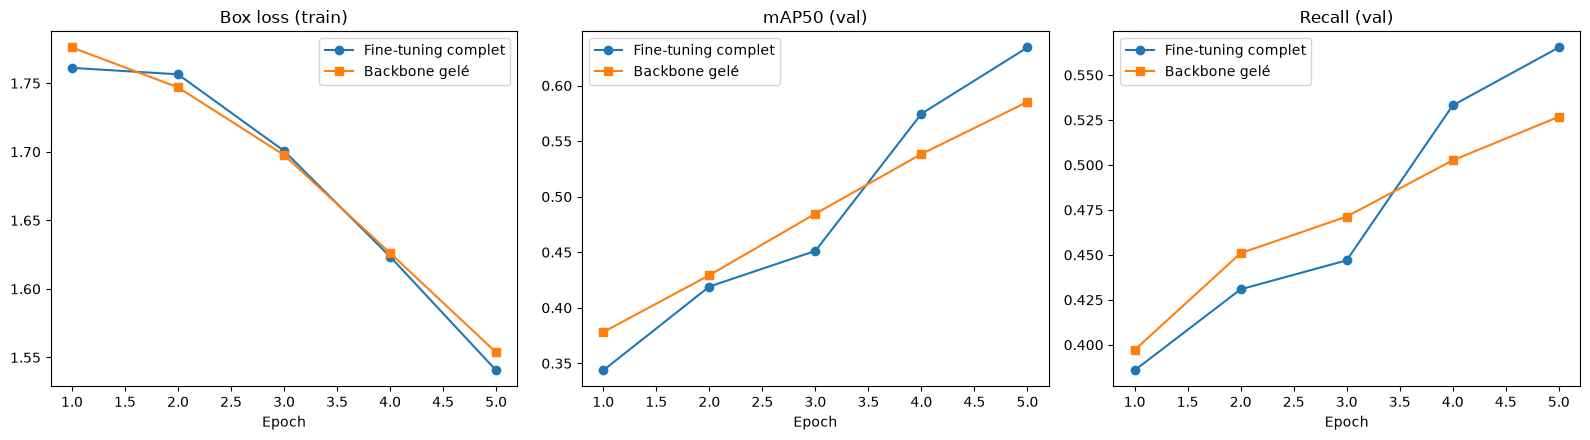

In [5]:
def load_results_csv(run_name):
    path = Path(f"../../runs/runs/prototype/{run_name}/results.csv")
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df

df_full = load_results_csv("full_finetune")
df_frozen = load_results_csv("frozen_backbone")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics_to_plot = [
    ("train/box_loss", "Box loss (train)"),
    ("metrics/mAP50(B)", "mAP50 (val)"),
    ("metrics/recall(B)", "Recall (val)"),
]

for ax, (col, title) in zip(axes, metrics_to_plot):
    if df_full is not None and col in df_full.columns:
        ax.plot(df_full["epoch"], df_full[col], label="Fine-tuning complet", marker="o")
    if df_frozen is not None and col in df_frozen.columns:
        ax.plot(df_frozen["epoch"], df_frozen[col], label="Backbone gelé", marker="s")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()


**Lecture des courbes** :
- Si le **backbone gelé** converge presque aussi bien que le fine-tuning complet
  → le dataset est probablement assez petit ou similaire à COCO pour se contenter
  d'entraîner la tête → gain de temps d'entraînement possible.
- Si le **fine-tuning complet** est nettement meilleur → les features spécifiques à la
  fumée/au feu (texture diffuse, faible contraste) nécessitent d'adapter le backbone
  → garder la stratégie par défaut de `src/train.py`.
- Une **loss train qui baisse mais un mAP val qui stagne/baisse** = signe de
  sur-apprentissage → réduire `epochs`, augmenter les données, ou renforcer les
  augmentations (`mosaic`, `copy_paste`, déjà activées dans `train.py`).

## 4. Test rapide de sensibilité au learning rate

In [3]:
lr_candidates = [0.01, 0.05] # 0.001, 0.01, 0.05
lr_results = {}

for lr in lr_candidates:
    m = YOLO("yolov8n.pt")
    res = m.train(
        data=DATA_CONFIG,
        epochs=3,
        imgsz=416,
        batch=8,
        device="CPU",
        lr0=lr,
        project="../runs/prototype",
        name=f"lr_{lr}",
        verbose=False,
        plots=False,
    )
    # df = load_results_csv(f"lr_{lr}")
    # lr_results[lr] = df["metrics/mAP50(B)"].iloc[-1] if df is not None else None

# pd.DataFrame(lr_results.items(), columns=["learning_rate", "mAP50_final"])


New https://pypi.org/project/ultralytics/8.4.142 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.129  Python-3.11.6 torch-2.13.0+cpu CPU (AMD Ryzen 7 5800X 8-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/smoke.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

In [6]:
lr_candidates = [0.001, 0.01, 0.05]
lr_results = {}

for lr in lr_candidates:
    df = load_results_csv(f"lr_{lr}")
    lr_results[lr] = df["metrics/mAP50(B)"].iloc[-1] if df is not None else None

pd.DataFrame(lr_results.items(), columns=["learning_rate", "mAP50_final"])

,learning_rate,mAP50_final
0,0.001,0.54439
1,0.010,0.53666
2,0.050,0.53666
